# Gapminder 1: Data Manipulation
**ENGR 1451 / 2451 · Exploratory Data Analytics**

**Focus:** load → filter and select → create columns → summarize → save.

Keep `data/gapminder.csv` in a `data` folder beside this notebook. Run from top to bottom;
before saving your work, restart the kernel and run all cells. This notebook runs independently
of Parts 2 and 3. The exercise is left for you to complete.

## 1. Load and inspect the data
Each row is a **country–year observation**, not a person. This historical excerpt contains
**1,704 rows: 142 countries at 12 time points, from 1952 through 2007**.

| Column | Meaning |
|:--|:--|
| `country` | Historical country label |
| `continent` | Continent group |
| `year` | Observation year |
| `lifeExp` | Life expectancy at birth, in years |
| `pop` | Population, in people |
| `gdpPercap` | GDP per capita, in inflation-adjusted US dollars |

In [9]:
from pathlib import Path
import pandas as pd

gapminder = pd.read_csv(Path("data/gapminder.csv"))
print(f"Rows: {gapminder.shape[0]:,}; columns: {gapminder.shape[1]}")
gapminder.head()

Rows: 1,704; columns: 6


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [10]:
gapminder.info()
gapminder[["lifeExp", "pop", "gdpPercap"]].describe().round(2)

<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   continent  1704 non-null   str    
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), str(2)
memory usage: 80.0 KB


,lifeExp,pop,gdpPercap
count,1704.00,1.704000e+03,1704.00
mean,59.47,2.960121e+07,7215.33
std,12.92,1.061579e+08,9857.45
min,23.60,6.001100e+04,241.17
25%,48.20,2.793664e+06,1202.06
50%,60.71,7.023596e+06,3531.85
75%,70.85,1.958522e+07,9325.46
max,82.60,1.318683e+09,113523.13


## 2. Filter, select, and sort
Use `.loc[row_condition, column_names]` to select rows and columns together.
Combine conditions with `&` (**and**) or `|` (**or**), with parentheses around each condition.
Use `==` to compare values.

In [11]:
gapminder.loc[
    (gapminder["country"] == "Rwanda") & (gapminder["year"] > 1979),
    ["country", "year", "lifeExp"],
]

,country,year,lifeExp
1290,Rwanda,1982,46.218
1291,Rwanda,1987,44.020
1292,Rwanda,1992,23.599
1293,Rwanda,1997,36.087
1294,Rwanda,2002,43.413
1295,Rwanda,2007,46.242


In [12]:
# A one-year snapshot: one row per country.
gap_2007 = gapminder.loc[gapminder["year"] == 2007].copy()

# Method chaining: filter, then sort, then show the first five rows.
(
    gap_2007.loc[:, ["country", "continent", "lifeExp", "gdpPercap"]]
    .sort_values("lifeExp", ascending=False)
    .head(8)
)

,country,continent,lifeExp,gdpPercap
803,Japan,Asia,82.603,31656.06806
671,"Hong Kong, China",Asia,82.208,39724.97867
695,Iceland,Europe,81.757,36180.78919
1487,Switzerland,Europe,81.701,37506.41907
71,Australia,Oceania,81.235,34435.36744
1427,Spain,Europe,80.941,28821.06370
1475,Sweden,Europe,80.884,33859.74835
767,Israel,Asia,80.745,25523.27710


## 3. Create columns
`assign()` returns a new DataFrame. Column arithmetic is vectorized.
Here population is converted to millions and total GDP to billions of the dataset's dollars.

In [13]:
gap_2007 = gap_2007.assign(
    pop_millions=gap_2007["pop"] / 1_000_000,
    gdp_billions=gap_2007["pop"] * gap_2007["gdpPercap"] / 1_000_000_000,
)

gap_2007[["country", "pop_millions", "gdpPercap", "gdp_billions"]].head()

,country,pop_millions,gdpPercap,gdp_billions
11,Afghanistan,31.889923,974.580338,31.079292
23,Albania,3.600523,5937.029526,21.376411
35,Algeria,33.333216,6223.367465,207.444852
47,Angola,12.420476,4797.231267,59.583896
59,Argentina,40.301927,12779.379640,515.033625


## 4. Group and summarize
Each named aggregation has the form `new_name=("column", "operation")`.
`agg()` returns one row per continent. These 2007 summaries give each country equal weight;
they are **not population-weighted**. `std` uses the sample standard deviation, with denominator $n-1$.

In [14]:
continent_summary = (
    gap_2007.groupby("continent", as_index=False)
    .agg(
        n_countries=("country", "nunique"),
        mean_life_exp=("lifeExp", "mean"),
        median_life_exp=("lifeExp", "median"),
        s_life_exp=("lifeExp", "std"),
    )
)
continent_summary.round(2)

,continent,n_countries,mean_life_exp,median_life_exp,s_life_exp
0,Africa,52,54.81,52.93,9.63
1,Americas,25,73.61,72.90,4.44
2,Asia,33,70.73,72.40,7.96
3,Europe,30,77.65,78.61,2.98
4,Oceania,2,80.72,80.72,0.73


### Exercise 1 — Build a useful comparison table
For **2007**, select countries in the **Americas** with populations greater than **10 million**.
Show `country`, `lifeExp`, `pop_millions`, and `gdpPercap`, sorted from highest to lowest life expectancy.
Does the country with the highest life expectancy also have the highest GDP per capita?

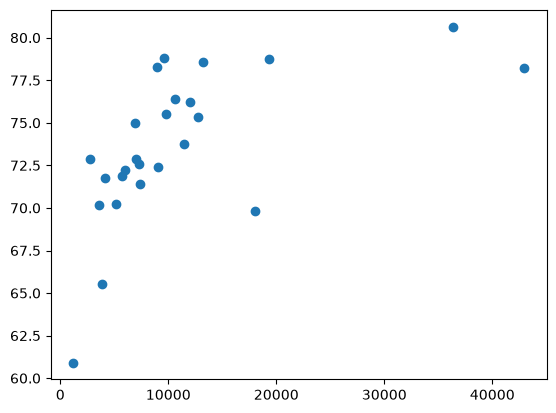

In [15]:
# Your code here.
gap_americas_07 = gap_2007.loc[gap_2007["continent"] == "Americas"]
gap_americas_07_10mil = gap_americas_07.loc[gap_americas_07["pop"] > 1e7]
gap_americas_07_10mil.sort_values("lifeExp",ascending=False)
gap_americas_07_10mil[["country","lifeExp","pop_millions","gdpPercap"]] #showing desired columns

import matplotlib.pyplot as plt
plt.scatter(gap_americas_07["gdpPercap"],gap_americas_07["lifeExp"])

**Your interpretation:**

_Write one or two sentences here._

## 5. Save the summary table
`index=False` omits the row-index column. Rerunning this cell replaces the generated CSV,
not the input data.

In [16]:
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)
table_path = output_dir / "gapminder_continent_summary_2007.csv"
continent_summary.to_csv(table_path, index=False)
print(f"Saved: {table_path}")

Saved: outputs\gapminder_continent_summary_2007.csv


---
## Command reference
| Task | Python pattern |
|:--|:--|
| Read a CSV | `pd.read_csv(path)` |
| Inspect | `df.head()`, `df.info()`, `df.describe()` |
| Filter and select | `df.loc[condition, ["country", "lifeExp"]]` |
| Sort | `df.sort_values("lifeExp", ascending=False)` |
| Create a column | `df.assign(pop_millions=df["pop"] / 1e6)` |
| Group and summarize | `df.groupby("continent").agg(mean_life_exp=("lifeExp", "mean"))` |
| Save a CSV | `df.to_csv(path, index=False)` |
